In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

In [4]:
file_path = "../data/ai_student_impact_dataset.csv"

In [5]:
df = pd.read_csv(file_path)
df

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,149996,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,149997,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium
49997,149998,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High
49998,149999,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium


## Dataset Overview

In [108]:
df.shape

(50000, 16)

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

In [116]:
list(df.columns)

['Student_ID',
 'Major_Category',
 'Year_of_Study',
 'Pre_Semester_GPA',
 'Weekly_GenAI_Hours',
 'Primary_Use_Case',
 'Prompt_Engineering_Skill',
 'Tool_Diversity',
 'Paid_Subscription',
 'Traditional_Study_Hours',
 'Perceived_AI_Dependency',
 'Institutional_Policy',
 'Anxiety_Level_During_Exams',
 'Post_Semester_GPA',
 'Skill_Retention_Score',
 'Burnout_Risk_Level']

In [118]:
df.nunique()

Student_ID                    50000
Major_Category                    5
Year_of_Study                     5
Pre_Semester_GPA               2389
Weekly_GenAI_Hours             3566
Primary_Use_Case                  5
Prompt_Engineering_Skill          3
Tool_Diversity                    5
Paid_Subscription                 2
Traditional_Study_Hours        2516
Perceived_AI_Dependency          10
Institutional_Policy              3
Anxiety_Level_During_Exams       10
Post_Semester_GPA              2269
Skill_Retention_Score          5872
Burnout_Risk_Level                3
dtype: int64

In [110]:
df.sample(5)

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
38316,138317,Humanities,Junior,3.008,1.64,Copywriting/Drafting,Advanced,3,False,19.01,2,Strict_Ban,4,3.245,92.53,Low
6658,106659,STEM,Sophomore,2.802,2.70,Summarizing_Reading,Beginner,1,False,8.87,2,Allowed_With_Citation,4,2.938,62.50,Low
47302,147303,Business,Graduate,2.298,5.17,Ideation,Intermediate,2,False,12.42,1,Strict_Ban,3,2.912,66.07,High
1373,101374,Humanities,Freshman,2.765,6.69,Copywriting/Drafting,Intermediate,3,True,8.34,4,Actively_Encouraged,4,2.796,58.34,Low
3247,103248,Humanities,Junior,3.834,16.47,Summarizing_Reading,Advanced,5,True,5.22,6,Allowed_With_Citation,7,3.948,69.67,Medium


In [183]:
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


## Missing Value

In [ ]:
df.isnull().sum()

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

In [269]:
df.duplicated().sum()

np.int64(0)

## Categorical Columns

In [202]:
df.describe(include=["object", "bool"])

/var/folders/xx/g7stg62x21n5v52bwc3h6yq00000gn/T/ipykernel_81418/3729900875.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=['object', 'bool'])


,Major_Category,Year_of_Study,Primary_Use_Case,Prompt_Engineering_Skill,Paid_Subscription,Institutional_Policy,Burnout_Risk_Level
count,50000,50000,50000,50000,50000,50000,50000
unique,5,5,5,3,2,3,3
top,STEM,Junior,Debugging/Troubleshooting,Beginner,False,Allowed_With_Citation,Medium
freq,15059,11045,12295,18495,28846,25224,21144


This dataset contains 7 catagorical columns.

Key Observations:
- **STEM** is the most common major category with 15059 people.
- **Junior** is the frequent year of study with 11045 people.
- **Debugging/Troubleshooting**	is the most common primary use case of Generative AI.
- Most of student have **Beginner** skill of prompt engineering.
- Most frequent institutional policy is **Allowed with Citation**.
- Most students have **Medium** burnout risk level (21144 students).
- There are more students who **DO NOT** pay for AI subscriptions than those who do."



In [205]:
categorical_columns = df.select_dtypes(include=["object", "bool"]).columns
list(categorical_columns)

/var/folders/xx/g7stg62x21n5v52bwc3h6yq00000gn/T/ipykernel_81418/3883900996.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object", "bool"]).columns


['Major_Category',
 'Year_of_Study',
 'Primary_Use_Case',
 'Prompt_Engineering_Skill',
 'Paid_Subscription',
 'Institutional_Policy',
 'Burnout_Risk_Level']

In [185]:
df["Major_Category"].value_counts()

Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64

In [186]:
df["Year_of_Study"].value_counts()

Year_of_Study
Junior       11045
Freshman     11031
Senior       10634
Sophomore     9860
Graduate      7430
Name: count, dtype: int64

In [187]:
df["Primary_Use_Case"].value_counts()

Primary_Use_Case
Debugging/Troubleshooting    12295
Copywriting/Drafting         12011
Ideation                     10721
Summarizing_Reading           8633
Direct_Answer_Generation      6340
Name: count, dtype: int64

In [188]:
df["Prompt_Engineering_Skill"].value_counts()

Prompt_Engineering_Skill
Beginner        18495
Intermediate    17696
Advanced        13809
Name: count, dtype: int64

In [189]:
df["Institutional_Policy"].value_counts()

Institutional_Policy
Allowed_With_Citation    25224
Actively_Encouraged      14988
Strict_Ban                9788
Name: count, dtype: int64

In [190]:
df["Paid_Subscription"].value_counts()

Paid_Subscription
False    28846
True     21154
Name: count, dtype: int64

## Numerical Columns

In [142]:
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


In [195]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols

['Student_ID',
 'Pre_Semester_GPA',
 'Weekly_GenAI_Hours',
 'Tool_Diversity',
 'Traditional_Study_Hours',
 'Perceived_AI_Dependency',
 'Anxiety_Level_During_Exams',
 'Post_Semester_GPA',
 'Skill_Retention_Score']

In [7]:
numerical_columns = [
    "Pre_Semester_GPA",
    "Weekly_GenAI_Hours",
    "Tool_Diversity",
    "Traditional_Study_Hours",
    "Perceived_AI_Dependency",
    "Anxiety_Level_During_Exams",
    "Post_Semester_GPA",
    "Skill_Retention_Score",
]

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


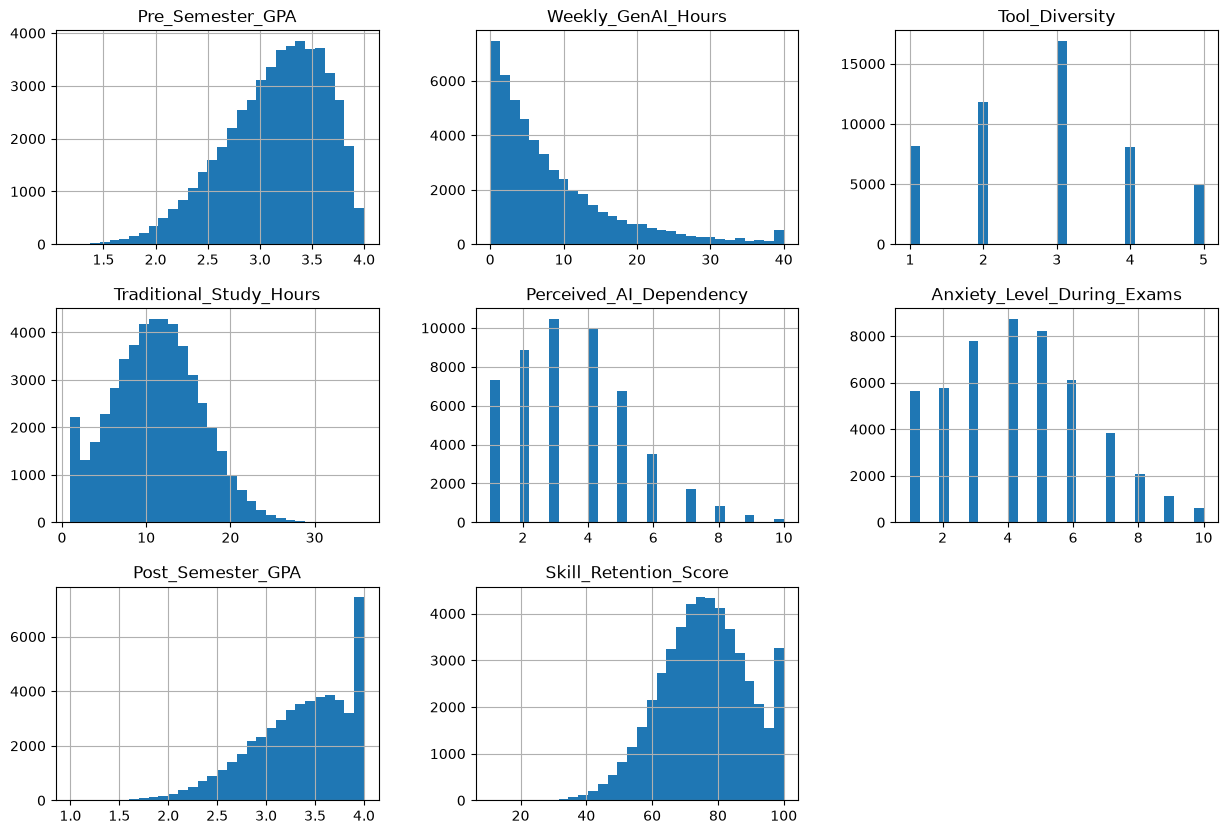

In [197]:
df[numerical_columns].hist(bins=30, figsize=(15, 10))
df[numerical_columns].describe()

<Axes: >

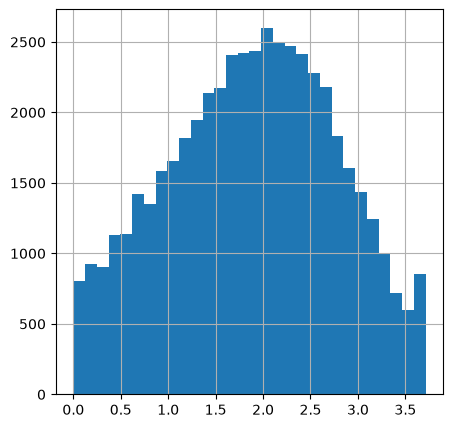

In [ ]:
# transform log to weeky genAI hours
transformed_genai_hours = df["Weekly_GenAI_Hours"].apply(lambda x: np.log1p(x))
transformed_genai_hours.hist(bins=30, figsize=(5, 5))

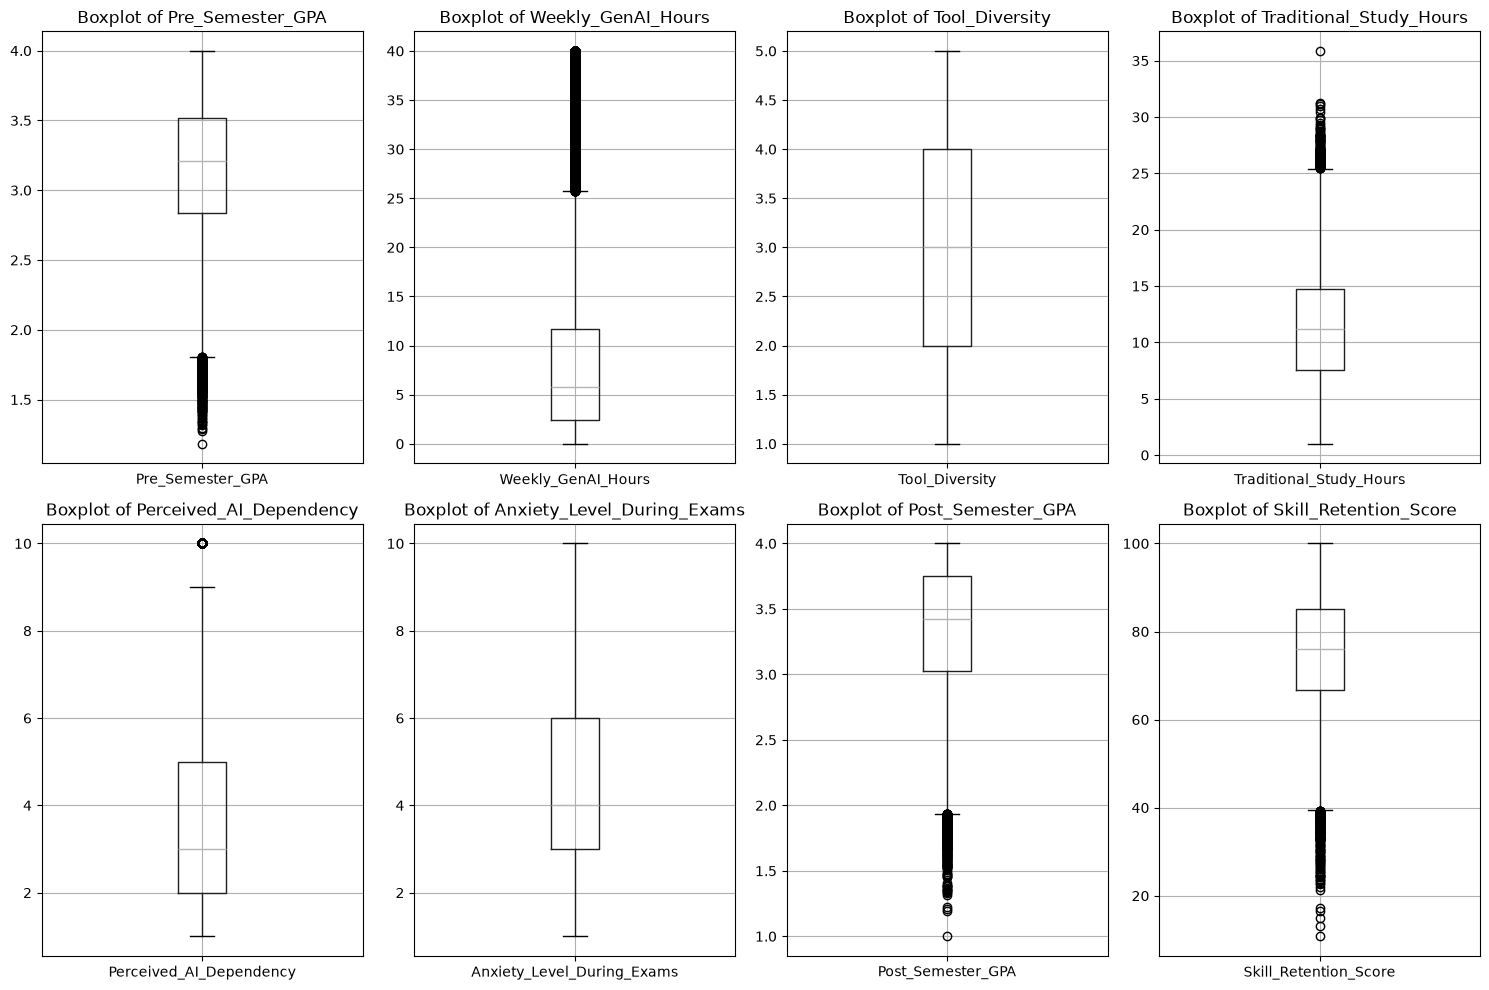

In [198]:
fig, axes = plt.subplots(2, 4, figsize=(15, 10))

for i, col in enumerate(numerical_columns):
    df.boxplot(column=col, ax=axes[i // 4, i % 4])
    axes[i // 4, i % 4].set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

## Target Understanding

In [279]:
burnout_order = ["Low", "Medium", "High"]

Class counts:
Burnout_Risk_Level
Medium    21144
Low       16369
High      12487
Name: count, dtype: int64

Imbalance Ratio: 1.69:1


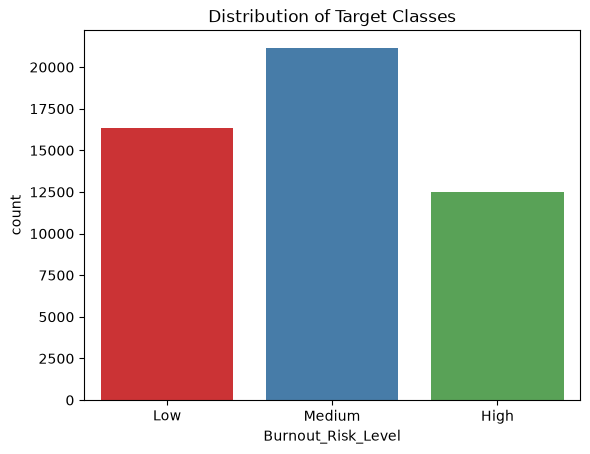

In [ ]:
# check class imbalance
class_counts = df["Burnout_Risk_Level"].value_counts()
sns.countplot(
    x="Burnout_Risk_Level",
    data=df,
    order=burnout_order,
    palette="Set1",
    hue_order=burnout_order,
    hue="Burnout_Risk_Level",
)
plt.title("Distribution of Target Classes")

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Class counts:\n{class_counts}\n")
print(f"Imbalance Ratio: {imbalance_ratio:.2f}:1")

In [ ]:
pd.crosstab(
    df["Institutional_Policy"], df["Burnout_Risk_Level"], normalize="index"
).round(4)

Burnout_Risk_Level,High,Low,Medium
Institutional_Policy,,,
Actively_Encouraged,0.2377,0.3389,0.4234
Allowed_With_Citation,0.2383,0.3298,0.4319
Strict_Ban,0.2976,0.3034,0.3990


With each Institutional Policy have level of burnout risk:
- Actively_Encouraged 
    high   23.77%
    **medium 42.34%**
    low    33.89%
- Allowed_With_Citation
    high   23.83%
    **medium 43.19%**
    low    32.98%
- Strict_Ban
    high   29.76%
    **medium 39.90%**
    low    30.34%


**Key Observation**

- Most of students have medium level of burnout risk across all institutional policy.
- The highest percentage of **HIGH** burnout risk level is **Strict_Ban** Institutional Policy.
- The highest percentage of **MEDIUM** burnout risk level is **Allowed_With_Citation** Institutional Policy.
- The highest percentage of **LOW** burnout risk level is **Actively_Encouraged** Institutional Policy.

In [ ]:
pd.crosstab(df["Major_Category"], df["Burnout_Risk_Level"], normalize="index").round(4)

Burnout_Risk_Level,High,Low,Medium
Major_Category,,,
Arts,0.2269,0.3395,0.4337
Business,0.2433,0.3344,0.4222
Humanities,0.2074,0.3608,0.4318
Medical,0.2316,0.3464,0.4220
STEM,0.3000,0.2864,0.4136


Major_Category VS Burnout_Risk_Level

**Key Observation**

- Every major's highest percentage of level of burnout risk is **medium**.
- The highest percentage of **HIGH** burnout risk level is **STEM** major.
- The highest percentage of **MEDIUM** burnout risk level is **Arts** major.
- The highest percentage of **LOW** burnout risk level is **Humanities** Institutional Policy

In [ ]:
pd.crosstab(df["Year_of_Study"], df["Burnout_Risk_Level"], normalize="index").round(4)

Burnout_Risk_Level,High,Low,Medium
Year_of_Study,,,
Freshman,0.1798,0.4179,0.4023
Graduate,0.3672,0.2022,0.4307
Junior,0.2434,0.3248,0.4319
Senior,0.2741,0.2901,0.4358
Sophomore,0.2204,0.3636,0.4160


Year_of_Study VS Burnout_Risk_Level

**Key Observation**

- The highest percentage of **HIGH** burnout risk level is **Graduate** student.
- The highest percentage of **MEDIUM** burnout risk level is **Senior** major.
- The highest percentage of **LOW** burnout risk level is **Freshman** Institutional Policy

### Burnout Risk vs. GenAI Usage Intensity

Split students into five equal-sized groups (~10,000 each) by weekly GenAI hours,
then compare the burnout mix within each group.

In [ ]:
# Burnout risk across Weekly_GenAI_Hours quintiles (~10,000 students per group)
df["GenAI_Usage_Quintile"] = pd.qcut(df["Weekly_GenAI_Hours"], 5)

counts = pd.crosstab(df["GenAI_Usage_Quintile"], df["Burnout_Risk_Level"])[
    burnout_order
]
percent = (
    pd.crosstab(
        df["GenAI_Usage_Quintile"], df["Burnout_Risk_Level"], normalize="index"
    )[burnout_order]
    * 100
).round(1)

print("Students per quintile:")
print(counts.sum(axis=1).to_string())
print("\nCounts:")
print(counts.to_string())
print("\nPercent within quintile:")
print(percent.to_string())

percent.plot(
    kind="bar", stacked=True, figsize=(8, 5), color=["#2E7D32", "#F9A825", "#C62828"]
)
plt.title("Burnout Risk by Weekly GenAI Hours (quintiles)")
plt.ylabel("% of students in quintile")
plt.xlabel("Weekly GenAI Hours")
plt.xticks(rotation=20)
plt.legend(title="Burnout Risk")
plt.tight_layout()
plt.show()

**Key Observation**

- Burnout risk rises sharply with GenAI usage. From the lowest to the highest usage quintile:
    - **HIGH** risk grows from **8.8% to 61.0%** (886 -> 6,097 students)
    - **LOW** risk falls from **50.1% to 7.3%** (5,013 -> 728 students)
- **MEDIUM** stays between ~32-48% in *every* quintile, so it overlaps all usage levels
  and is the hardest class to separate. This explains the accuracy ceiling seen in modelling.

## Bivariate

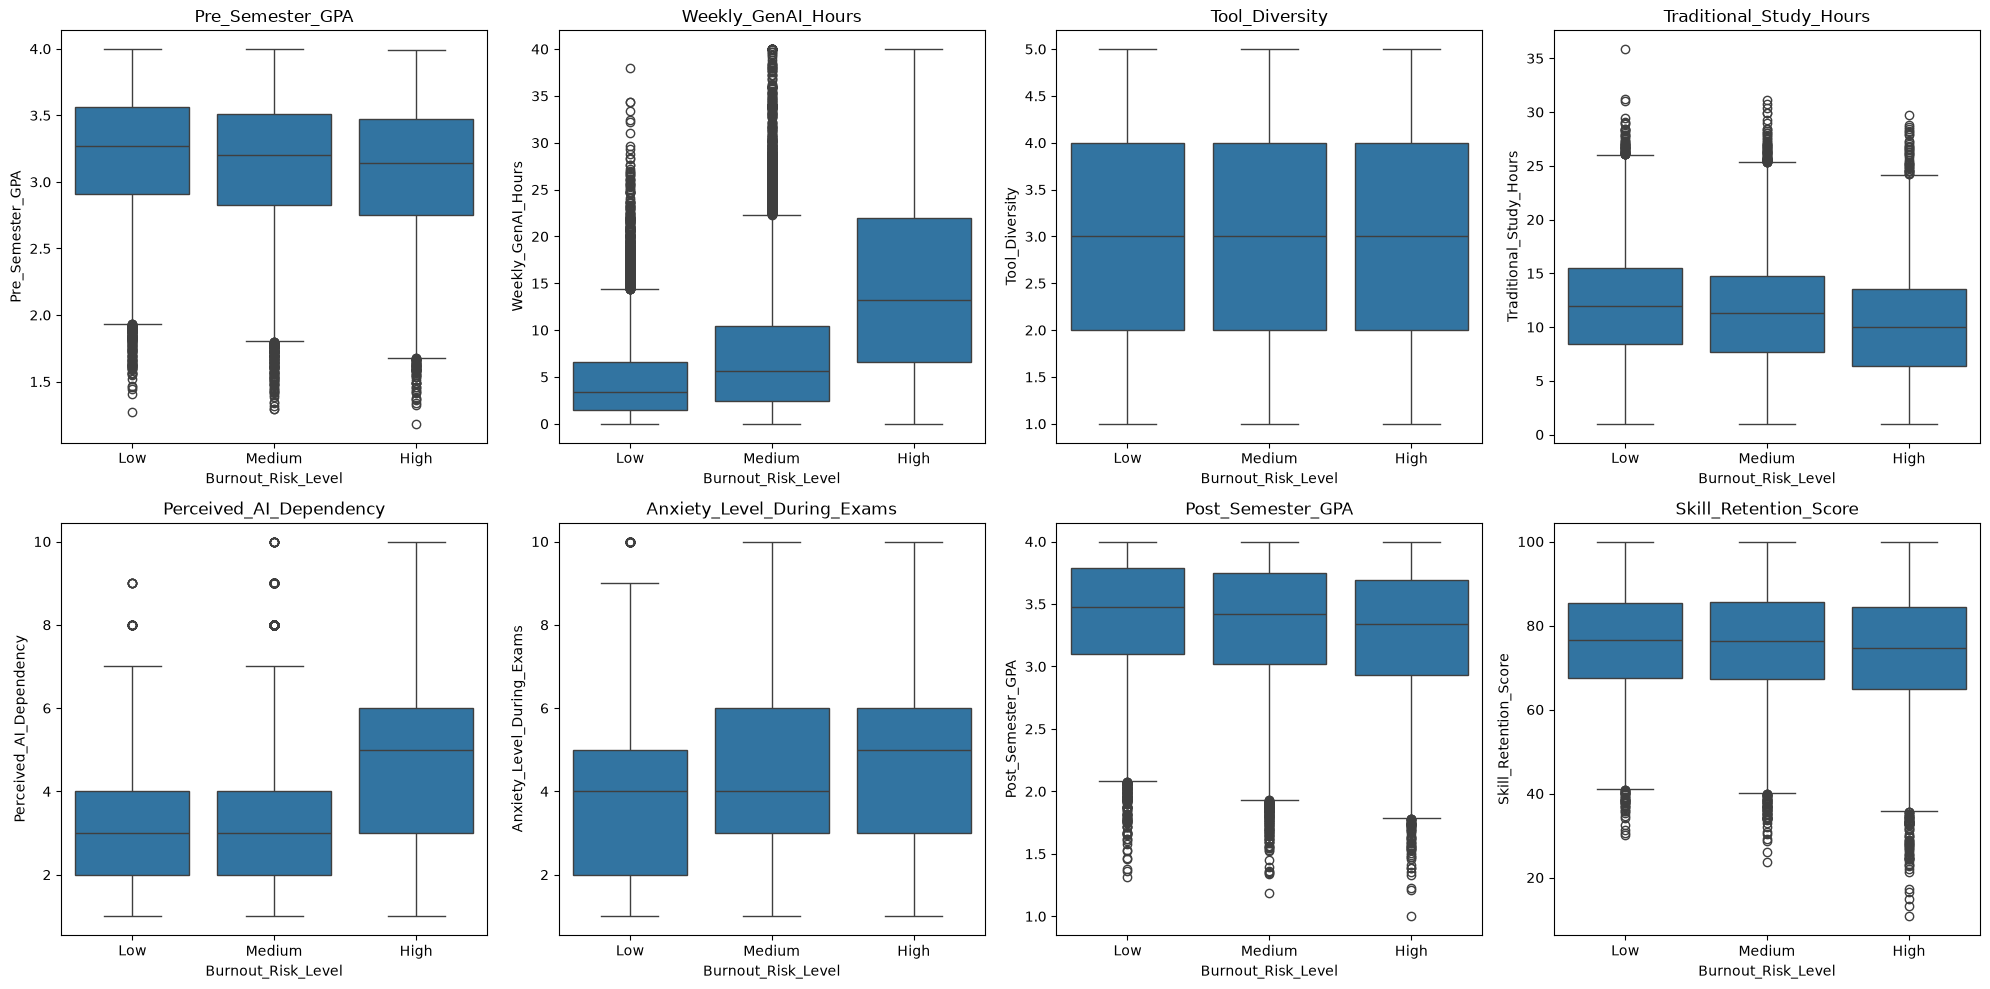

In [ ]:
# Numeric vs target: boxplots
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(numerical_columns):
    sns.boxplot(x="Burnout_Risk_Level", y=col, data=df, order=burnout_order, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

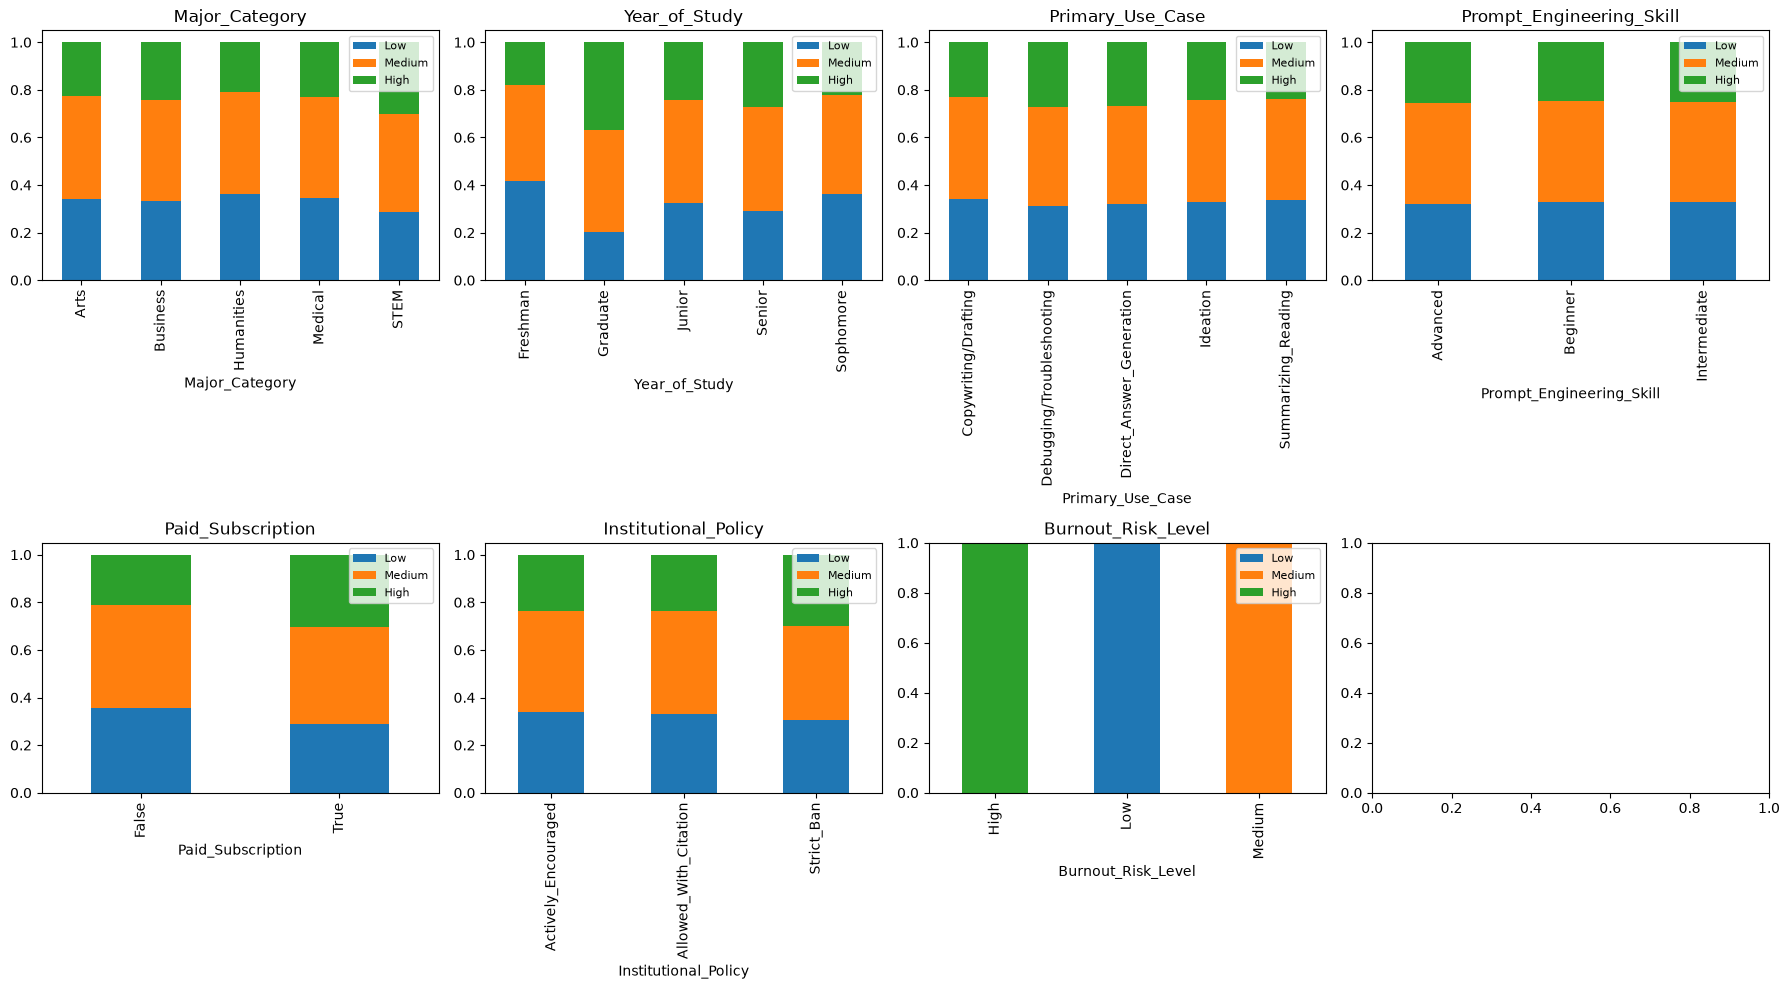

In [209]:
# Categorical vs target: stacked bars
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(categorical_columns):
    ct = pd.crosstab(df[col], df["Burnout_Risk_Level"], normalize="index")
    ct = ct[burnout_order]
    ct.plot(kind="bar", stacked=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## Correlation Analysis

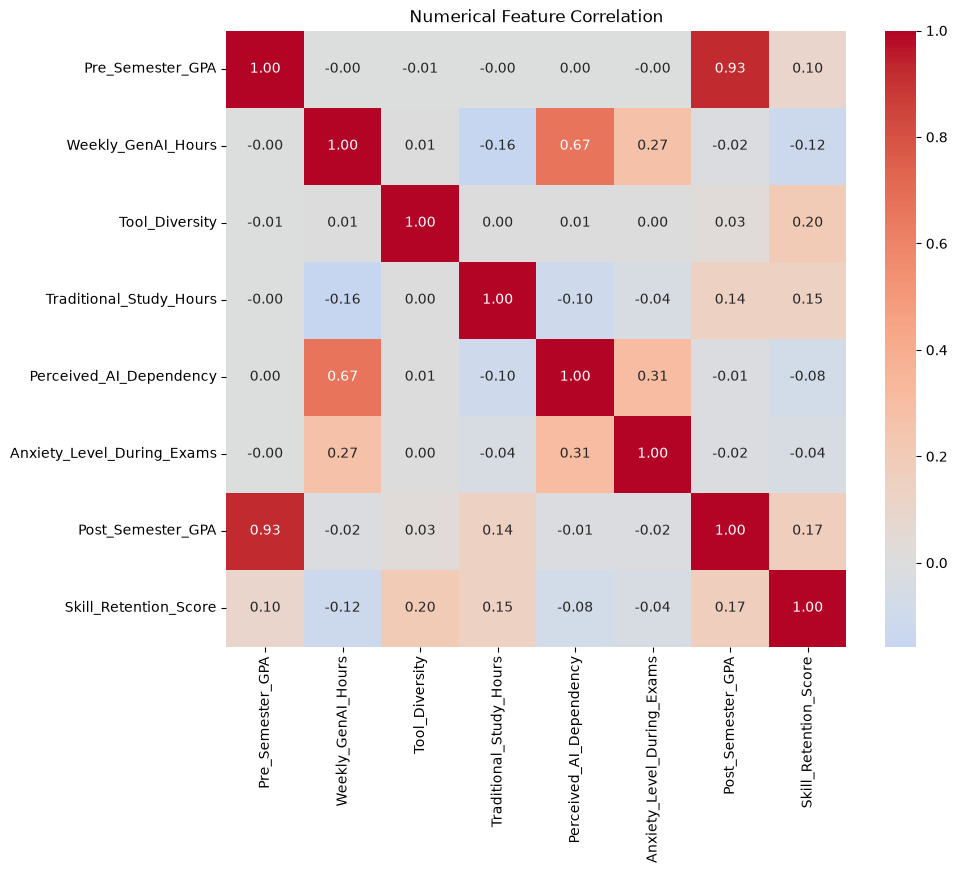

In [261]:
plt.figure(figsize=(10, 8))
corr = df[numerical_columns].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Numerical Feature Correlation")
plt.show()

**Key Observations**

- Pre Semester GPA and Post Semester GPA may correlate to each other.
- Perceived_AI_Dependency and Weekly_GenAI_Hours also have some correlation.


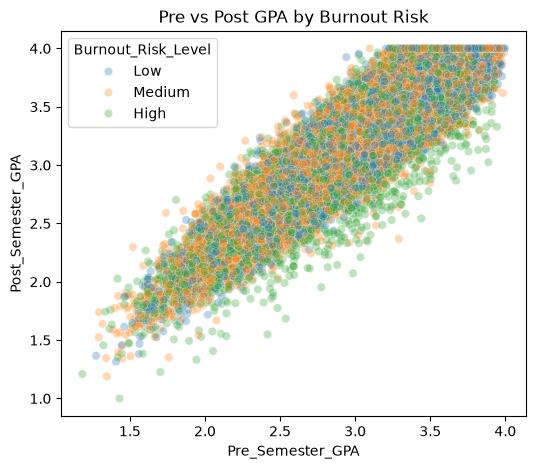

In [217]:
# Pre vs Post GPA, colored by burnout
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x="Pre_Semester_GPA",
    y="Post_Semester_GPA",
    hue="Burnout_Risk_Level",
    hue_order=burnout_order,
    data=df,
    alpha=0.3,
)
plt.title("Pre vs Post GPA by Burnout Risk")
plt.show()

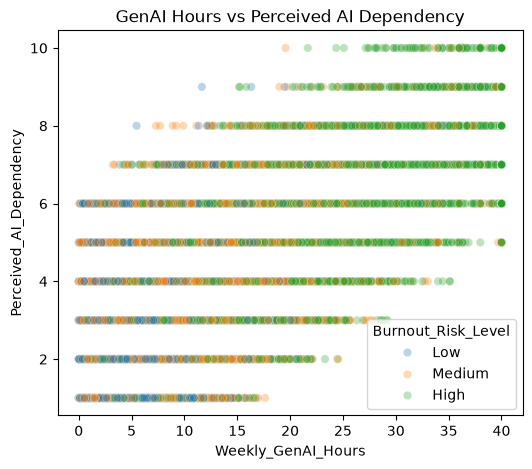

In [224]:
# Weekly_GenAI_Hours vs Perceived_AI_Dependency
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x="Weekly_GenAI_Hours",
    y="Perceived_AI_Dependency",
    data=df,
    alpha=0.3,
    hue="Burnout_Risk_Level",
    hue_order=burnout_order,
)
plt.title("GenAI Hours vs Perceived AI Dependency")
plt.show()

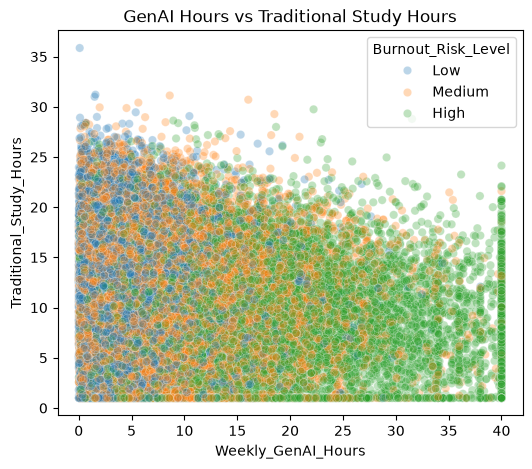

In [225]:
# Weekly_GenAI_Hours vs Traditional_Study_Hours
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x="Weekly_GenAI_Hours",
    y="Traditional_Study_Hours",
    data=df,
    alpha=0.3,
    hue="Burnout_Risk_Level",
    hue_order=burnout_order,
)
plt.title("GenAI Hours vs Traditional Study Hours")
plt.show()

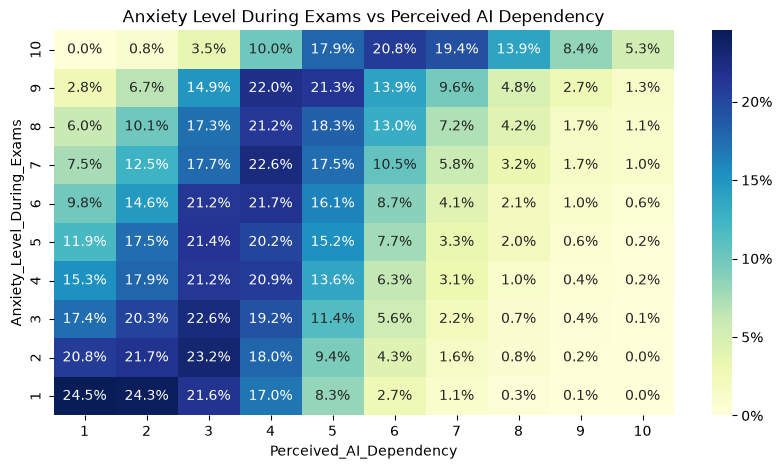

In [ ]:
# Anxiety_Level_During_Exams vs Perceived_AI_Dependency
plt.figure(figsize=(10, 5))
sns.heatmap(
    pd.crosstab(
        df["Anxiety_Level_During_Exams"],
        df["Perceived_AI_Dependency"],
        normalize="index",
    ).sort_index(ascending=False),
    annot=True,
    fmt=".1%",
    cmap="YlGnBu",
    cbar_kws={"format": FuncFormatter(lambda x, _: f"{x * 100:.0f}%")},
)
plt.title("Anxiety Level During Exams vs Perceived AI Dependency")
plt.show()

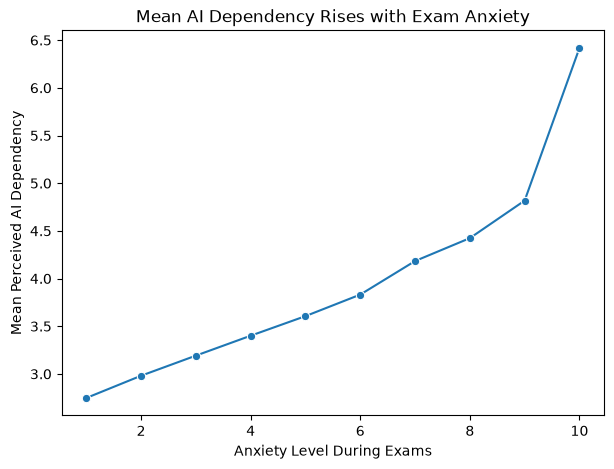

In [343]:
plt.figure(figsize=(7, 5))
means = df.groupby("Anxiety_Level_During_Exams")["Perceived_AI_Dependency"].mean()
sns.lineplot(x=means.index, y=means.values, marker="o")
plt.xlabel("Anxiety Level During Exams")
plt.ylabel("Mean Perceived AI Dependency")
plt.title("Mean AI Dependency Rises with Exam Anxiety")
plt.show()

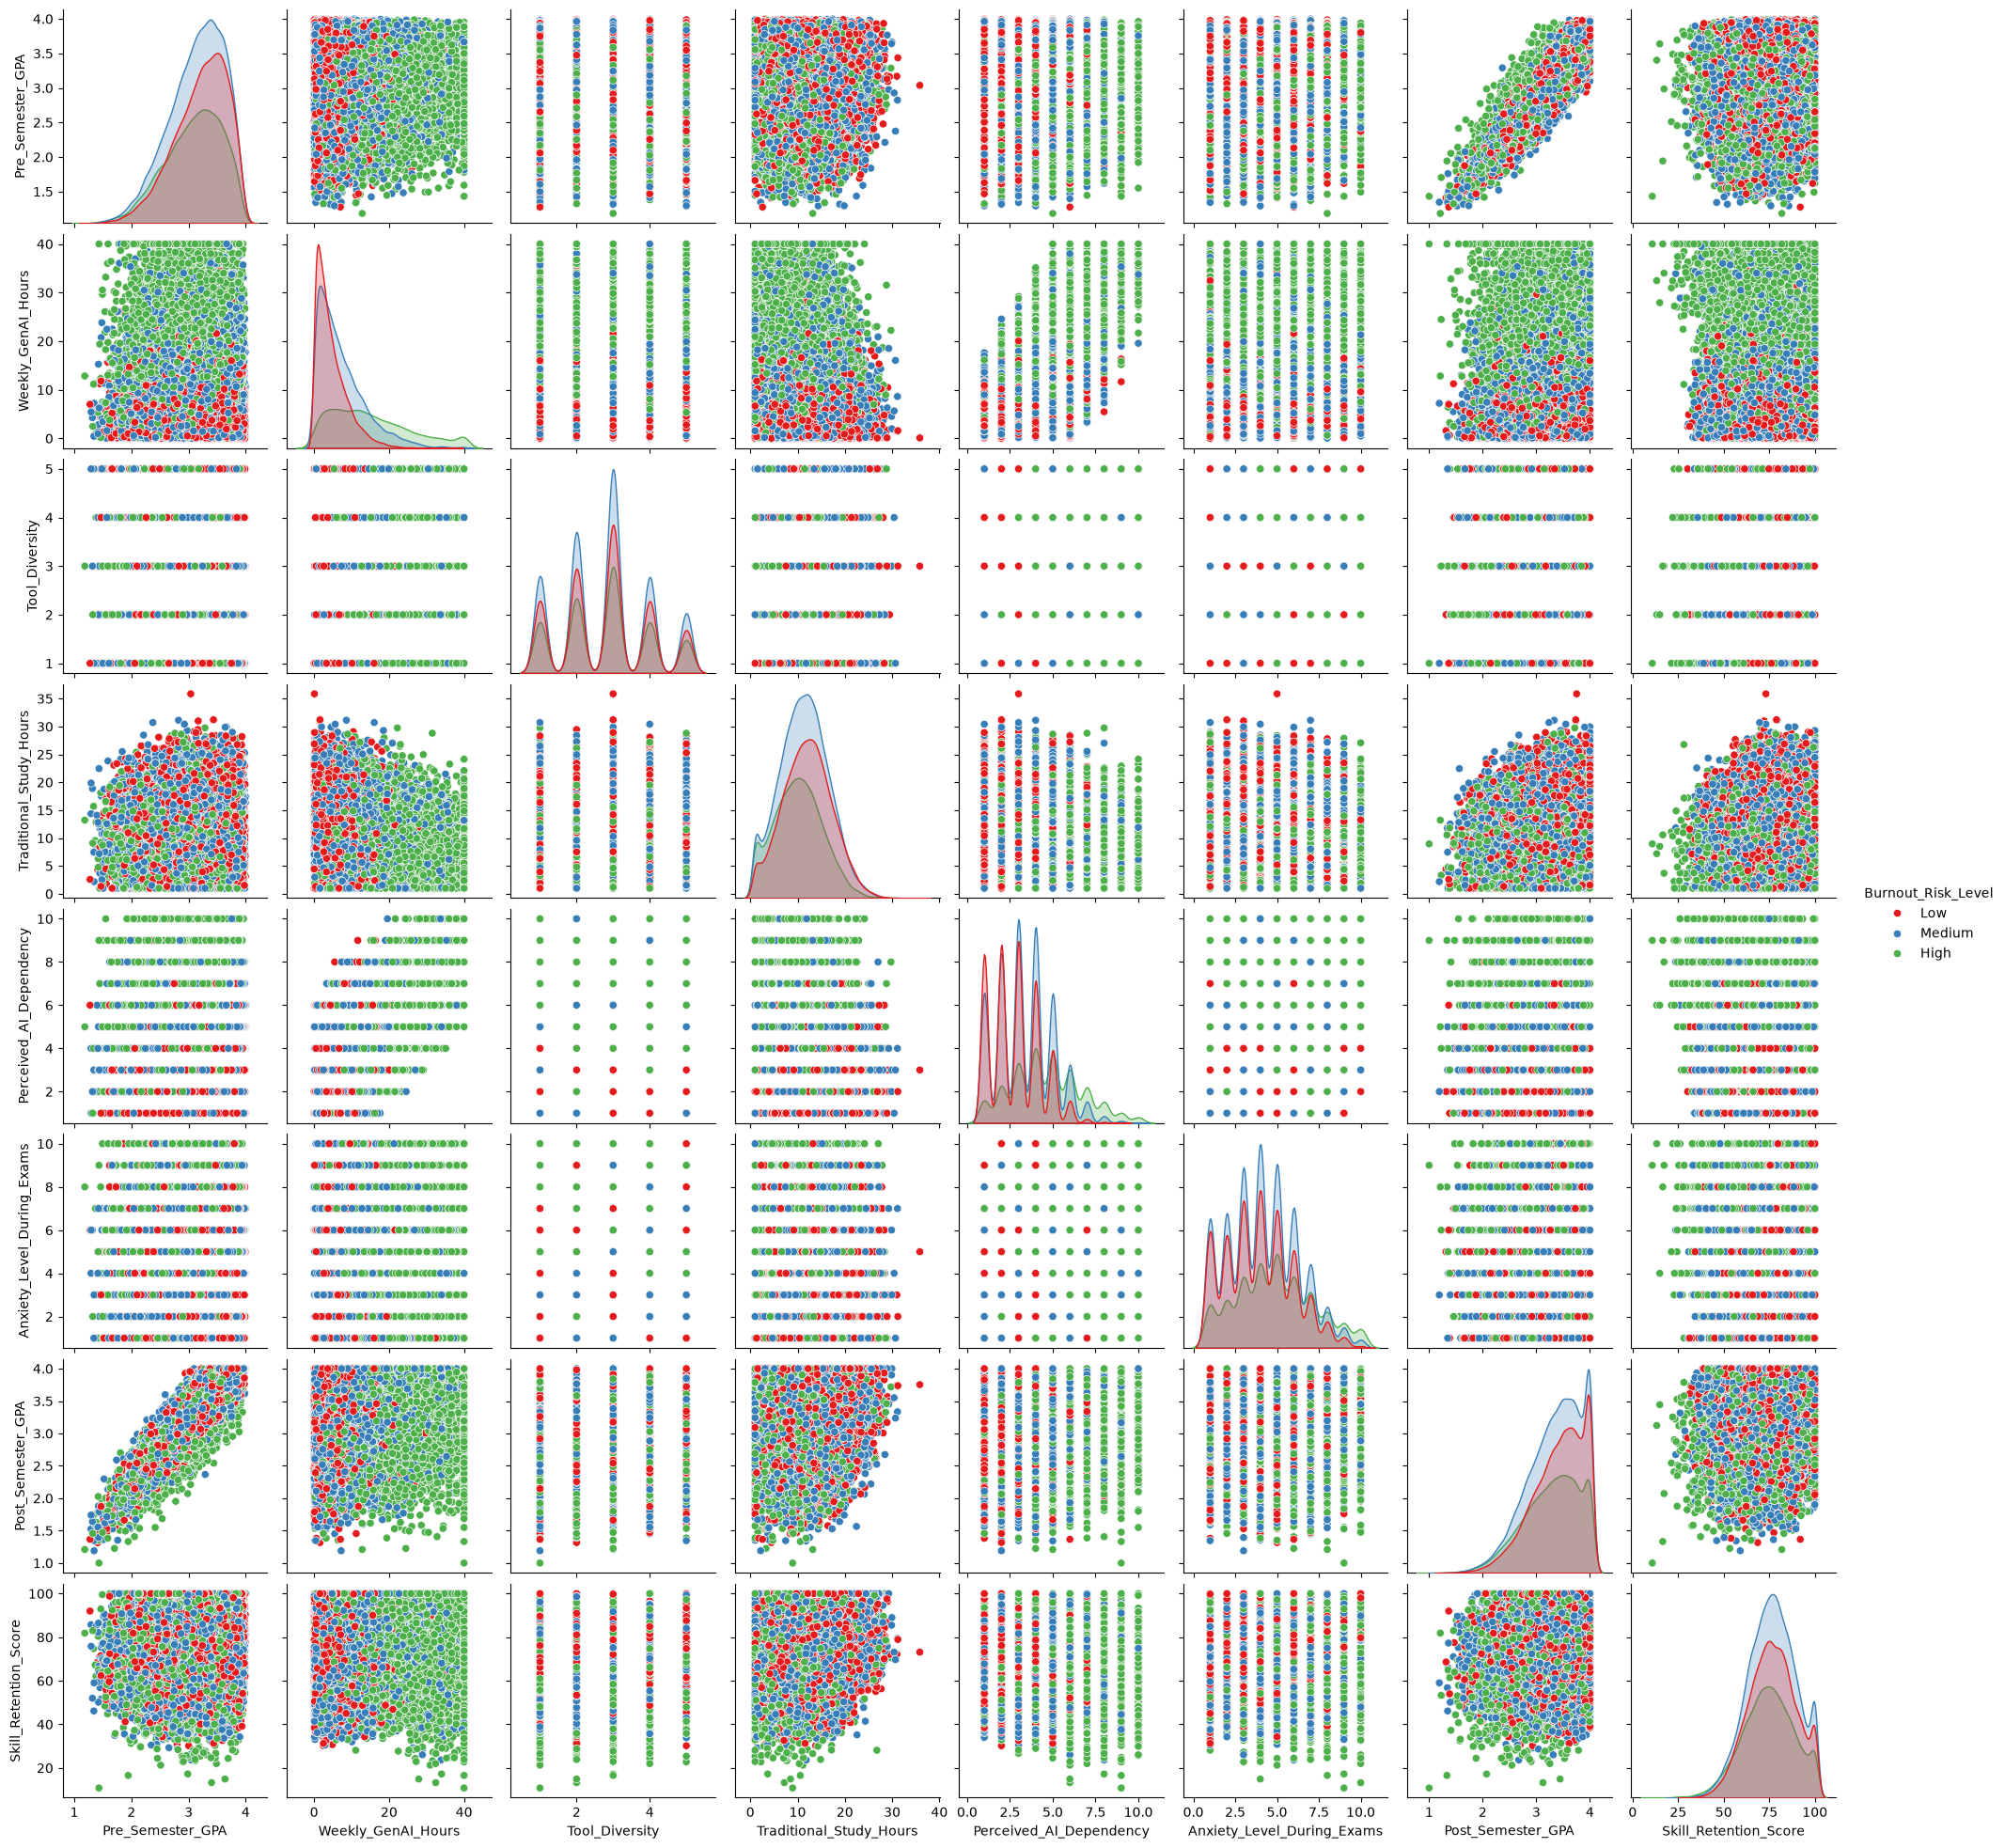

In [ ]:
sns.pairplot(
    df[numerical_columns + ["Burnout_Risk_Level"]],
    hue="Burnout_Risk_Level",
    palette="Set1",
    diag_kind="kde",
    hue_order=burnout_order,
)

## Data Quality 


In [272]:
# Impossible value checks
print(
    "GPA out of [0,4] range (Pre):",
    df[(df["Pre_Semester_GPA"] > 4) | (df["Pre_Semester_GPA"] < 0)].shape[0],
)
print(
    "GPA out of [0,4] range (Post):",
    df[(df["Post_Semester_GPA"] > 4) | (df["Post_Semester_GPA"] < 0)].shape[0],
)
print("Negative hours (GenAI):", df[df["Weekly_GenAI_Hours"] < 0].shape[0])
print("Negative hours (Traditional):", df[df["Traditional_Study_Hours"] < 0].shape[0])

GPA out of [0,4] range (Pre): 0
GPA out of [0,4] range (Post): 0
Negative hours (GenAI): 0
Negative hours (Traditional): 0


In [273]:
# IQR-based outlier counts per numeric column
for col in numeric_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {n_outliers} outliers (bounds: {lower:.2f} to {upper:.2f})")

Student_ID: 0 outliers (bounds: 75001.50 to 174999.50)
Pre_Semester_GPA: 328 outliers (bounds: 1.80 to 4.55)
Weekly_GenAI_Hours: 2583 outliers (bounds: -11.61 to 25.72)
Tool_Diversity: 0 outliers (bounds: -1.00 to 7.00)
Traditional_Study_Hours: 161 outliers (bounds: -3.17 to 25.44)
Perceived_AI_Dependency: 190 outliers (bounds: -2.50 to 9.50)
Anxiety_Level_During_Exams: 0 outliers (bounds: -1.50 to 10.50)
Post_Semester_GPA: 346 outliers (bounds: 1.94 to 4.84)
Skill_Retention_Score: 216 outliers (bounds: 39.26 to 112.75)


## Anomaly Detection

In [312]:
%pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 5.2 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [317]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# numeric features that describe behavior
anomaly_features = [
    "Weekly_GenAI_Hours",
    "Traditional_Study_Hours",
    "Tool_Diversity",
    "Perceived_AI_Dependency",
    "Anxiety_Level_During_Exams",
    "Skill_Retention_Score",
]

X_anomaly = df[anomaly_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_anomaly)

iso = IsolationForest(contamination=0.02, random_state=42)  # assume ~2% are anomalies
df["anomaly_score"] = iso.fit_predict(X_scaled)  # -1 = anomaly, 1 = normal
df["anomaly_score_raw"] = iso.decision_function(
    X_scaled
)  # continuous score, lower = more anomalous

print(df["anomaly_score"].value_counts())
df["anomaly_score_raw"].describe()

anomaly_score
 1    49000
-1     1000
Name: count, dtype: int64


count    50000.000000
mean         0.131249
std          0.048421
min         -0.114883
25%          0.104887
50%          0.138247
75%          0.166695
max          0.219980
Name: anomaly_score_raw, dtype: float64

In [322]:
anomaly_df = df.loc[df["anomaly_score"] == -1]
anomaly_df.sort_values(by="anomaly_score_raw").head(10)

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level,anomaly_score,anomaly_score_raw
29406,129407,STEM,Graduate,2.798,40.00,Direct_Answer_Generation,Intermediate,1,False,1.25,10,Allowed_With_Citation,9,2.230,36.80,High,-1,-0.114883
37096,137097,Business,Graduate,3.321,40.00,Direct_Answer_Generation,Intermediate,3,True,3.75,10,Allowed_With_Citation,10,2.735,26.00,High,-1,-0.104678
33712,133713,STEM,Junior,2.962,40.00,Direct_Answer_Generation,Advanced,3,True,2.33,10,Strict_Ban,10,2.493,25.66,High,-1,-0.102731
18078,118079,STEM,Junior,1.431,40.00,Direct_Answer_Generation,Beginner,1,True,8.95,9,Strict_Ban,9,1.000,10.78,High,-1,-0.098706
9566,109567,Business,Freshman,2.895,40.00,Direct_Answer_Generation,Advanced,5,True,2.22,9,Allowed_With_Citation,3,2.407,22.76,High,-1,-0.098455
19891,119892,STEM,Graduate,3.258,40.00,Direct_Answer_Generation,Advanced,4,True,11.13,10,Strict_Ban,10,2.778,41.33,High,-1,-0.095020
19177,119178,STEM,Junior,2.882,40.00,Direct_Answer_Generation,Beginner,2,True,1.00,8,Allowed_With_Citation,9,2.418,25.29,High,-1,-0.093464
21145,121146,Business,Senior,3.233,38.46,Direct_Answer_Generation,Beginner,2,False,1.00,8,Actively_Encouraged,1,2.615,28.14,High,-1,-0.093411
39170,139171,Business,Junior,2.683,40.00,Direct_Answer_Generation,Advanced,5,False,20.75,10,Strict_Ban,9,2.119,55.64,High,-1,-0.091300
38859,138860,STEM,Freshman,3.044,40.00,Direct_Answer_Generation,Beginner,3,True,7.27,10,Strict_Ban,10,2.465,36.57,High,-1,-0.091041


In [325]:
anomaly_df.groupby("Burnout_Risk_Level").size()

Burnout_Risk_Level
High      892
Low         3
Medium    105
dtype: int64

In [326]:
anomaly_df.groupby("Major_Category").size()

Major_Category
Arts           52
Business      236
Humanities     63
Medical        85
STEM          564
dtype: int64

In [ ]:
anomaly_df.groupby("Year_of_Study").size()

Year_of_Study
Freshman     235
Graduate     128
Junior       227
Senior       218
Sophomore    192
dtype: int64

In [330]:
anomaly_df.groupby("Institutional_Policy").size()

Institutional_Policy
Actively_Encouraged      240
Allowed_With_Citation    452
Strict_Ban               308
dtype: int64

**Key Observation**
- 892 of 1000 flagged anomalies (89%) are **HIGH** level of burnout risk students.
- 564 of 1000 anomalies (56%) are **STEM**.

In [12]:
year_ordinal = {"Freshman": 1, "Sophomore": 2, "Junior": 3, "Senior": 4, "Graduate": 5}
df["Year_of_Study_Ordinal"] = df["Year_of_Study"].map(year_ordinal)

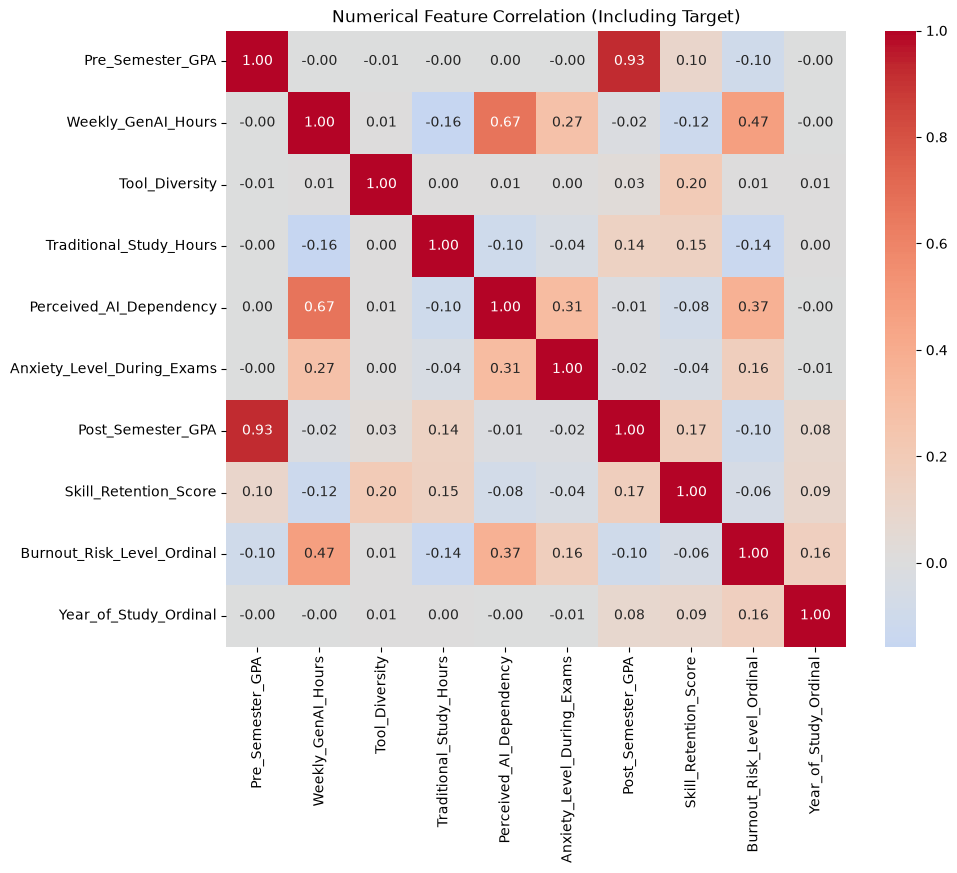

In [14]:
target_ordinal = {"Low": 0, "Medium": 1, "High": 2}
df["Burnout_Risk_Level_Ordinal"] = df["Burnout_Risk_Level"].map(target_ordinal)

plt.figure(figsize=(10, 8))
corr = df[
    numerical_columns + ["Burnout_Risk_Level_Ordinal"] + ["Year_of_Study_Ordinal"]
].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Numerical Feature Correlation (Including Target)")
plt.show()